In [59]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
data = pd.read_csv("data.csv")
print(df.head())

   COMP  AGE  EDUCATN  BACKGRD  TENURE  EXPER  SALES  VAL  PCNTOWN  PROF  \
0  1948   55        1        1      23   23.0   1227  7.6     0.55   145   
1   809   59        1        2      38    0.5  19196  0.4     0.01   505   
2   721   53        2        1      26    0.5    839  1.5     0.10   -60   
3  2027   62        2        2      25    5.0   8379  3.4     0.04   806   
4  2094   63        1        3      41    8.0  10818  5.9     0.04  1166   

  COMPANY   BIRTH  
0    AdvM     chi  
1   aetna     chi  
2   aller    sanf  
3    amer   vertx  
4   ameri  bigrun  


In [61]:
X = data.drop(columns=["COMP", "COMPANY", "BIRTH"])
#X = pd.get_dummies(X, drop_first=True)
#X = X.astype(float)
y = data["COMP"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   COMP   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     4.548
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           9.83e-05
Time:                        00:21:36   Log-Likelihood:                -638.77
No. Observations:                  80   AIC:                             1298.
Df Residuals:                      70   BIC:                             1321.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2035.2196    958.759      2.123      0.0

Бачимо, що модель в загальному є статистично значущою, про що свідчить F-статистика з відповідним p-value (тобто нульова гіпотеза про одночасну рівність нулю всіх коефіцієнтів відхиляється). З $R^2$ і відкоригованого $R^2$ можемо сказати, що модель має помірну, але не високу пояснювальну здатність (чим більший коеф, тим точнішим вважається прогноз). По регресорам: AGE, BACKGRD, TENURE, VAL - статистично незначущі (p > 0.05). На основі поточної моделі можна говорити, що досвід CEO (EXRER) та обсяг продажів (SALES) позитивно пов'язані з компенсацією, а відсоток власності CEO (PCNTOWN) - негативно. 

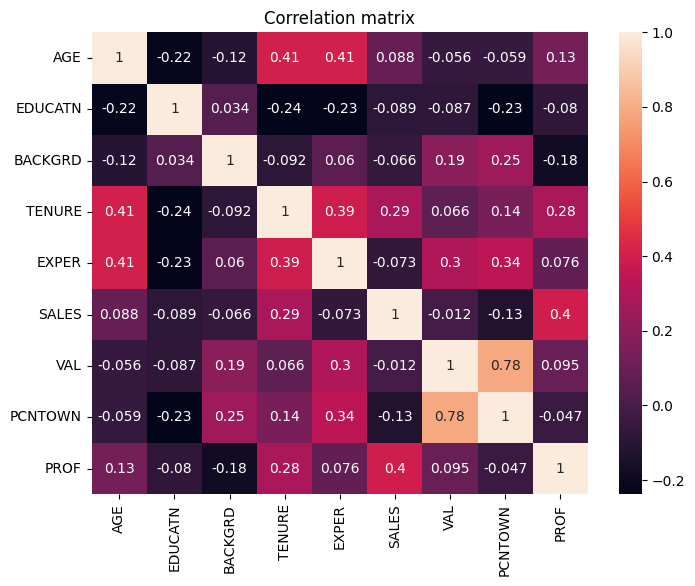

In [63]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True)
plt.title("Correlation matrix")
plt.show()

In [64]:
y_pred = model.predict(sm.add_constant(X_test))

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.16714047809066213
MSE: 313475.7707715308


Берем попередньо навчену модель на тренувальних даних і намагаємося передбачити значення COMP для тестових (які очевидно не брали участі в навчанні). Порівнюємо отримані значення з реальним. $R^2$ показує, яку частку варіації компенсації на нових, невідомих моделі даних вдалося пояснити. В нашому випадку модель пояснює лише 16.7% - це низький результат. 

MSE - це середньоквадратична помилка прогнозу. Вона показує, наскільки сильно в середньому помиляється модель (значення в квадраті). В нашому випадку це $sqrt(313475) = 559.9$ тис.дол. Тобто типова помилка прогнозу становить близько 560 тисяч доларів річної компенсації

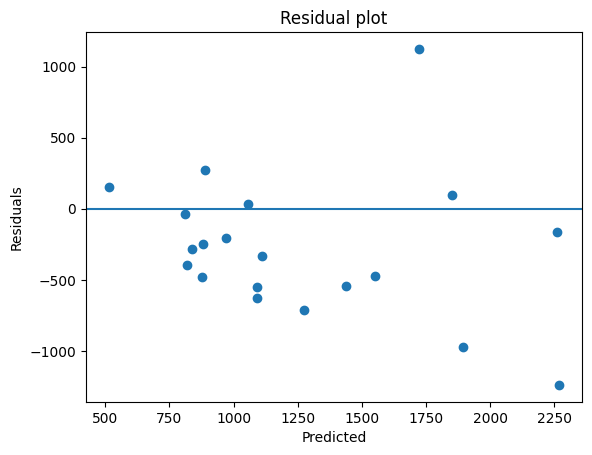

In [65]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()

Залишки розкидані як вище, так і нижче нульової лінії. Дисперсія залишків не є постійною - вона зростає зі збільшенням передбаченої компенсації. Це означає, що модель гірше прогнозує високі компенсації CEO, ніж низькі. Що звучить доволі логічно в реальності. 

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
lambdas = np.linspace(0.01, 100, 100)
best_r2 = -np.inf
best_lambda = None

for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_train_scaled, y_train)
    pred = ridge.predict(X_test_scaled)
    r2 = r2_score(y_test, pred)
    
    if r2 > best_r2:
        best_r2 = r2
        best_lambda = l

print("Best lambda:", best_lambda)
print("Best R2:", best_r2)

Best lambda: 48.49
Best R2: 0.20319511613253605


Ridge дав невелике покращення порівняно зі звичайною лінійною моделлю. Це звісно краще, але пояснювальна здатність моделі все ще залишається доволі низькою. А такий великий показник $lambda$ свідчить про те, що звичайна OLS-модель страждала від перенавчання. Ridge не вдалося нормально покращити результат, тож можемо зробити висновки, що набір змінних (TENURE, EXPER, SALES, VAL, PCNTOWN, PROF) сам по собі не здатний добре передбачати компенсацію CEO.

In [68]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

print("Polynomial R2:", r2_score(y_test, y_pred_poly))

Polynomial R2: -4.962479482038922


Катастрофічне перенавчання 😔 Від'ємний $R^2$ означає, що модель на тестових даних працює гірше, ніж просте передбачення середнім значенням компенсації у навчальній вибірці. Поліном другого ступеня для 6 змінних створює дуже велику кількість ознак. При цьому вибірка лише 100 спостережень. Модель отримує надто багато ступенів свободи і починає підганятися під кожну точку навчальної вибірки, повністю втрачаючи здатність до узагальнення.

In [69]:
print(model.pvalues)

const      0.037312
AGE        0.442940
EDUCATN    0.019187
BACKGRD    0.600893
TENURE     0.978683
EXPER      0.014339
SALES      0.018086
VAL        0.184077
PCNTOWN    0.018130
PROF       0.068934
dtype: float64


In [70]:
X_reduced = X_train.copy()

while True:
    X_sm = sm.add_constant(X_reduced)
    model_tmp = sm.OLS(y_train, X_sm).fit()
    
    max_p = model_tmp.pvalues.max()
    
    if max_p > 0.05:
        worst_feature = model_tmp.pvalues.idxmax()
        if worst_feature == "const":
            break
        X_reduced = X_reduced.drop(columns=[worst_feature])
    else:
        break

print("Selected features:", X_reduced.columns)

Selected features: Index(['EDUCATN', 'EXPER', 'SALES', 'PCNTOWN', 'PROF'], dtype='object')


In [71]:
model_reduced = sm.OLS(y_train, sm.add_constant(X_reduced)).fit()
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:                   COMP   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     7.750
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           6.61e-06
Time:                        00:22:21   Log-Likelihood:                -640.35
No. Observations:                  80   AIC:                             1293.
Df Residuals:                      74   BIC:                             1307.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1153.9455    280.077      4.120      0.0

У процесі відбору частина регресорів була видалена як статистично незначуща. Після цього модель була перебудована з меншою кількістю змінних. $R^2$ зменшився з 0.369 до 0.344. Це означає, що вилучені змінні (AGE, BACKGRD, TENURE, VAL) разом пояснювали лише близько 2.5% додаткової варіації компенсації. З практичної точки зору, ця втрата є прийнятною ціною за спрощення моделі. Скоригований $R^2$ навіть трохи підвищився. F-статистика значно покращилася. Тож як на мене, зменшення кількості регресорів було успішним.